# Comparison of path entropy with nexstrain


In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
import matplotlib as mpl
import os
import matplotlib.dates as mdates
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from sklearn.metrics import roc_curve, auc


from utils_mean_field import *
from script_mean_field_covid import *

main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "covid/")

from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
ab_names=list(ESCAPE_VECTORS.keys())


e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
rbd_df=pd.read_csv('../covid/gisaid/rbd_df.csv')
rbd_df.columns

Index(['sequence', 'count', 'date_of_100th', 'q05_date'], dtype='object')

In [ ]:
records = []
for index, row in rbd_df.iterrows():
    records.append(SeqRecord(
        Seq(row['sequence']),
        id=str(index),
        description="" 
    ))

output_file = "../covid/gisaid/sequences_rbd_df.fasta"
SeqIO.write(records, output_file, "fasta")

print(f"Successfully created {output_file}")

Successfully created ../covid/gisaid/sequences_rbd_df.fasta


# Order params

In [4]:
wt_seq=WT[BEGIN:-END]
dir = '../mean_field_theory/results_scripts/covid_D_20/'
paths=['mean_f_free_ab_beta_ab_5_D_1.npy']
labels=['beta_Ab=5' ]

# Site wise analysis

In [ ]:

mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})


SITE_OFFSET = 349  

path_entropies_all = {} 

for i, condition in enumerate(labels):

 
    path_proba = np.load(os.path.join(dir, paths[i])) 
    print(f"Processing: {condition}")

    last_step_probs = path_proba[:, -1, :]
 
    epsilon = 1e-12
    site_entropies = -np.sum(last_step_probs * np.log(last_step_probs + epsilon), axis=0)
    
    path_entropies_all[condition] = site_entropies
    print(f"Computed entropies for {len(site_entropies)} sites at last step.")
    print(f"Mean Entropy: {np.mean(site_entropies):.4f}\n")


    print(f"Top 20 sites by entropy for {condition}:")
    top_indices=np.argsort(site_entropies)[-20:]
    for idx in top_indices:
        site_number = SITE_OFFSET + idx  
        entropy_value = site_entropies[idx]
        print(f"Site {site_number}: Entropy = {entropy_value:.4f}")
    print("\n")

path_entropies_all

Processing: beta_Ab=5
Computed entropies for 178 sites at last step.
Mean Entropy: 0.0909

Top 20 sites by entropy for beta_Ab=5:
Site 494: Entropy = 0.2766
Site 514: Entropy = 0.2805
Site 457: Entropy = 0.3735
Site 376: Entropy = 0.3786
Site 417: Entropy = 0.3863
Site 391: Entropy = 0.3888
Site 452: Entropy = 0.3920
Site 356: Entropy = 0.4960
Site 486: Entropy = 0.5284
Site 408: Entropy = 0.6078
Site 445: Entropy = 0.6127
Site 518: Entropy = 0.6590
Site 519: Entropy = 0.6713
Site 383: Entropy = 0.6810
Site 385: Entropy = 0.7147
Site 357: Entropy = 0.7487
Site 490: Entropy = 0.7697
Site 440: Entropy = 0.7821
Site 487: Entropy = 1.0523
Site 496: Entropy = 1.2625




{'beta_Ab=5': array([3.98688678e-04, 2.97053272e-04, 4.64323958e-03, 3.52166918e-02,
        8.51746287e-04, 2.65488803e-02, 6.06126027e-03, 4.95967201e-01,
        7.48721627e-01, 4.01665293e-03, 9.90254221e-03, 4.44590852e-03,
        1.26358399e-03, 5.65038088e-02, 9.41818533e-02, 2.44738655e-03,
        8.21008886e-03, 3.08410875e-02, 1.18924567e-01, 1.12705380e-02,
        5.74468015e-02, 4.13211534e-02, 2.92517392e-02, 2.07029925e-02,
        9.96969139e-02, 3.39879903e-02, 2.57848393e-01, 3.78562355e-01,
        6.47637070e-03, 2.20274363e-03, 1.12945686e-02, 6.52632537e-03,
        2.66574462e-08, 1.25768192e-01, 6.80983297e-01, 4.19060664e-02,
        7.14688920e-01, 1.03945526e-01, 2.75914172e-02, 2.23327006e-02,
        9.38299054e-02, 1.33228263e-01, 3.88825302e-01, 7.32654687e-03,
        1.32739157e-02, 2.13098911e-01, 8.91531788e-03, 2.54500187e-02,
        3.47324885e-04, 9.69419056e-03, 6.67246025e-04, 5.73547314e-04,
        1.45735831e-03, 6.21615963e-03, 9.48212086e

Loading GISAID summary...
Processing: beta_Ab=5


<>:97: SyntaxWarning: invalid escape sequence '\%'
<>:98: SyntaxWarning: invalid escape sequence '\g'
<>:97: SyntaxWarning: invalid escape sequence '\%'
<>:98: SyntaxWarning: invalid escape sequence '\g'
C:\Users\maria\AppData\Local\Temp\ipykernel_25052\1033756133.py:97: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Model site entropy percentile rank (\%)")
C:\Users\maria\AppData\Local\Temp\ipykernel_25052\1033756133.py:98: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel("Average observed site\nmutations (frequency $\ge$ 100)")
C:\Users\maria\AppData\Local\Temp\ipykernel_25052\1033756133.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="best")


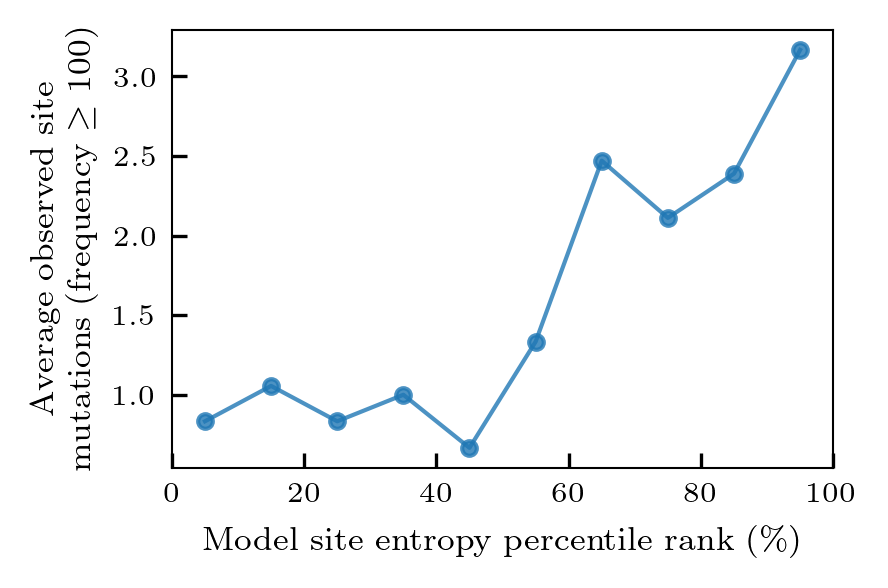

In [ ]:

GISAID_PATH = "../covid/gisaid/all_mutation_summary.csv"
SITE_OFFSET = 349  
N_BINS = 10        

# Style settings
mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 600,
    "axes.linewidth": 0.5, "lines.linewidth": 1., "lines.markersize": 3.5,
    "font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "font.family": "serif", "mathtext.fontset": "stix",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "text.usetex": True
})


print("Loading GISAID summary...")
df_base = pd.read_csv(GISAID_PATH)
df_base["first_seen_100"] = pd.to_datetime(df_base["first_seen_100"], errors='coerce')

df_seen = df_base.dropna(subset=["first_seen_100"]).copy()

def extract_site(mut_str):
    try:
        return int(mut_str[1:-1])
    except:
        return -1

df_seen['site_num'] = df_seen['mutation'].apply(extract_site)


observed_counts_map = df_seen.groupby('site_num')['mutation'].nunique().to_dict()


plot_data = {} 

for i, condition in enumerate(labels):
    print(f"Processing: {condition}")
    
    path_proba = np.load(os.path.join(dir, paths[i])) 
    
    last_step_probs = path_proba[:, -1, :] 
    epsilon = 1e-12
    site_entropies = -np.sum(last_step_probs * np.log(last_step_probs + epsilon), axis=0)
    

    ranks = np.argsort(np.argsort(site_entropies))
    n_sites = len(site_entropies)
    percentiles = (ranks / (n_sites - 1)) * 100
    

    bin_edges = np.linspace(0, 100, N_BINS + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    bin_means = []
    
    for b in range(N_BINS):
        low, high = bin_edges[b], bin_edges[b+1]
        if b == N_BINS - 1:
            mask = (percentiles >= low) & (percentiles <= high)
        else:
            mask = (percentiles >= low) & (percentiles < high)
            
        site_indices = np.where(mask)[0]
        
        counts_in_bin = []
        for idx in site_indices:
            real_site_num = SITE_OFFSET + idx
            counts_in_bin.append(observed_counts_map.get(real_site_num, 0))
            
        if len(counts_in_bin) > 0:
            bin_means.append(np.mean(counts_in_bin))
        else:
            bin_means.append(np.nan)
            
    plot_data[condition] = (bin_centers, bin_means)


fig, ax = plt.subplots(figsize=(3., 2.), dpi=300)

markers = ["o", "^", "D", "s", "v"]
colors  = ["#1f77b4", "#ff7f0e", "#0d100d", "#d62728", "#9467bd"] 

for i, (condition, (x_vals, y_vals)) in enumerate(plot_data.items()):
    if condition != "beta_Ab=5":
        continue
        
    style_idx = i % len(markers)
    ax.plot(x_vals, y_vals, 
            marker=markers[style_idx], 
            color=colors[style_idx],
            alpha=0.8)

ax.set_xlabel("Model site entropy percentile rank (\%)")
ax.set_ylabel("Average observed site\nmutations (frequency $\ge$ 100)")

ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))

ax.tick_params(direction="in", which="both", top=False, right=False)
ax.legend(frameon=False, loc="best")

plt.tight_layout()
plt.show()